In [2]:
from directional_coupler import DirectionalCoupler2D
from ybranch import YBranch2D
from mmi_2x2 import MMI2x2PowerSplitter2D
from waveguide_crossing import WaveguideCrossing2D
from euler_bend_device import EulerZigZag2D

import numpy as np
from utils import plot_fields_2d
from conditioning_masks import make_source_mask
import matplotlib as mpl
import matplotlib.pyplot as plt

# Avoid imshow smoothing/artifacts on pixel grids (important for eps/masks)
mpl.rcParams["image.interpolation"] = "nearest"
mpl.rcParams["image.resample"] = False

import os
import itertools
import multiprocessing as mp
from pathlib import Path

In [2]:
yb = YBranch2D(
    wg_width_um=0.6,
    wavelength_um=1.6,
    resolution=30,

    # geometry knobs
    l_junction_um=3.5,
    l_bend_um=8,
    h_bend_um=1.2,
    l_out_um=15,

    # optional: override the 13-width junction profile
    # junction_widths_um=[0.45, 0.5, 0.6, 0.8, 1.0, 1.2, 1.3, 1.3, 1.25, 1.1, 1.0, 0.9, 0.9],

    # optional: override cell size if you change lengths a lot
    # cell_x_um=36,
    # cell_y_um=10,
)

mmi = MMI2x2PowerSplitter2D(
    wg_width_um=0.45,
    wavelength_um=1.5,
    resolution=30,
    w_mmi_um=1.2,
    l_mmi_um=8,
    gap_um=0.2,
    s_bend_offset_um=1.0,
    s_bend_length_um=6,
    l_input_um=2.0,
    l_output_um=4.5,
)

cr = WaveguideCrossing2D(
    wg_width_um=0.45,
    wavelength_um=1.55,
    resolution=25,
    dpml=1.0,
    cell_x_um=32.0,
    cell_y_um=6.4,
)


# yb.plot_geometry()
# dc.plot_geometry()
# mmi.plot_geometry()
#dc.plot_geometry()


-----------
Initializing structure...
time for choose_chunkdivision = 0.00242519 s
Working in 2D dimensions.
Computational cell is 20.5 x 20.5 x 0 with resolution 20


     block, center = (0,0.365,0)
          size (9,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (0,-0.365,0)
          size (9,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-9.07604,1.36493,0)
          size (0.0503125,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-9.02812,1.3644,0)
          size (0.0503125,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-8.98021,1.36333,0)
          size (0.0503125,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-8.93229,1.36172,0)
          si

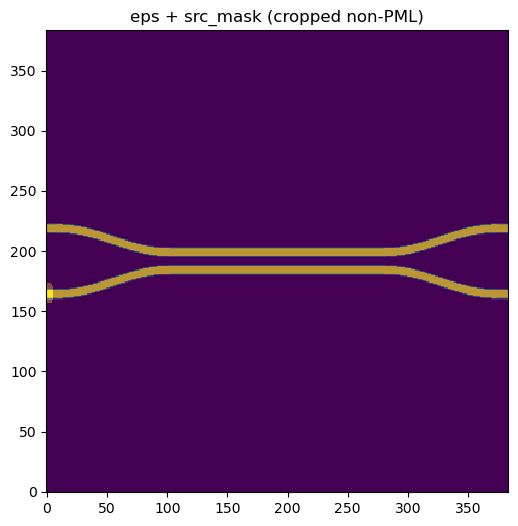

-----------
Initializing structure...
time for choose_chunkdivision = 0.002069 s
Working in 2D dimensions.
Computational cell is 20.5 x 20.5 x 0 with resolution 20
     block, center = (0,0.365,0)
          size (9,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (0,-0.365,0)
          size (9,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-9.07604,1.36493,0)
          size (0.0503125,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-9.02812,1.3644,0)
          size (0.0503125,0.38,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.26926,4.26926,4.26926)
     block, center = (-8.98021,1.36333,0)
          size (0.0503125,0.38,1e+20)
      

MPB solved for frequency_1(1.33304,0,0) = 0.697758 after 15 iters
MPB solved for frequency_1(1.23003,0,0) = 0.645034 after 6 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 1 iters
on time step 741 (time=18.525), 0.00540422 s/step
on time step 1465 (time=36.625), 0.00552901 s/step
on time step 2202 (time=55.05), 0.00543118 s/step
on time step 2913 (time=72.825), 0.00562627 s/step
on time step 3676 (time=91.9), 0.00524398 s/step
on time step 4449 (time=111.225), 0.00517738 s/step
on time step 5219 (time=130.475), 0.0051964 s/step
on time step 5940 (time=148.5), 0.00555394 s/step
on time step 6677 (time=166.925), 0.0054305 s/step
on time step 7419 (time=185.475), 0.00539589 s/step
on time step 8190 (time=204.75), 0.00519071 s/step
on time step 8989 (time=224.725), 0.00500918 s/step


run 0 finished at t = 226.8 (9072 timesteps)
MPB solved for frequency_1(1.33304,0,0) = 0.697758 after 15 iters
MPB solved for frequency_1(1.23003,0,0) = 0.645034 after 6 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.230278,-0.000000,0.000000)


MPB solved for frequency_1(1.33304,0,0) = 0.697758 after 15 iters
MPB solved for frequency_1(1.23003,0,0) = 0.645034 after 6 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.230278,-0.000000,0.000000)


MPB solved for frequency_1(1.33304,0,0) = 0.697758 after 15 iters
MPB solved for frequency_1(1.23003,0,0) = 0.645034 after 6 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.230278,-0.000000,0.000000)


MPB solved for frequency_1(1.33304,0,0) = 0.697758 after 15 iters
MPB solved for frequency_1(1.23003,0,0) = 0.645034 after 6 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.23028,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.230278,-0.000000,0.000000)
S-params for input_port=2:
S12 = (0.01618117950120195+0.007089006704127474j)  |S|^2=0.0003121
S22 = (0.0760479218822905-0.07908389012535329j)  |S|^2=0.01204
S32 = (0.6756352816528068+0.5108677047054351j)  |S|^2=0.7175
S42 = (-0.14643263074878854+0.1953550860613666j)  |S|^2=0.05961


In [5]:
# ---- Euler-aligned grid: 384x384 non-PML, res=20 ----
CROP_PX = 384
RES = 20
DPML = 2.0 / 3.0  # quantizes to pml_px=13 at res=20

dc = DirectionalCoupler2D(
    wg_width_um=0.38,
    gap_um=0.35,
    wg_length_um=9.0,        # 15 won't fit in 384@20 with margins; use <= ~12
    wavelength_um=1.55,
    resolution=RES,
    dpml=DPML,
    crop_px=CROP_PX,
    lead_extra_gap_um=2,    # 3.0 likely breaks y-fit in 384@20; keep <= ~2
    bend_length_um=6.0,       # 7 won't fit; keep <= ~3
    bend_n_segments=96,
)

# Get epsilon cropped to non-PML so it matches training shape
eps, (Lx, Ly) = dc.get_eps_and_cell(crop_pml=True)
ny, nx = eps.shape
assert (ny, nx) == (CROP_PX, CROP_PX)

# Build source mask for input_port=2 using the new pixel-accurate helper
src_px = dc.get_source_region_px(input_port=2, crop_pml=True)

def _draw_thick_line_mask(ny: int, nx: int, x0: float, y0: float, x1: float, y1: float, thickness_px: int = 3) -> np.ndarray:
    x0f, y0f, x1f, y1f = float(x0), float(y0), float(x1), float(y1)
    vx = x1f - x0f
    vy = y1f - y0f
    vv = vx * vx + vy * vy
    if vv < 1e-9:
        m = np.zeros((ny, nx), dtype=np.float32)
        xi = int(np.clip(round(x0f), 0, nx - 1))
        yi = int(np.clip(round(y0f), 0, ny - 1))
        m[yi, xi] = 1.0
        return m

    yy, xx = np.indices((ny, nx), dtype=np.float32)
    t = ((xx - x0f) * vx + (yy - y0f) * vy) / vv
    t = np.clip(t, 0.0, 1.0)
    px = x0f + t * vx
    py = y0f + t * vy
    d2 = (xx - px) ** 2 + (yy - py) ** 2
    thr2 = float(thickness_px * thickness_px)
    return (d2 <= thr2).astype(np.float32)

src_mask = _draw_thick_line_mask(
    ny, nx,
    src_px["line_start_px"][0], src_px["line_start_px"][1],
    src_px["line_end_px"][0],   src_px["line_end_px"][1],
    thickness_px=3,
)

plt.figure(figsize=(6, 6))
plt.imshow(eps, origin="lower")
plt.imshow(src_mask, origin="lower", alpha=0.35)
plt.title("eps + src_mask (cropped non-PML)")
plt.show()

# Run sim (full cell fields returned), then crop to non-PML to match eps/masks
eps_full, Ez_full, Hx_full, Hy_full, S, cell = dc.run_sim(input_port=2, decay_tol=1e-6)

pml_px = dc.pml_px()
eps_sim = np.asarray(eps_full, dtype=np.float32)[pml_px:-pml_px, pml_px:-pml_px]
Ez_sim  = np.asarray(Ez_full,  dtype=np.complex64)[pml_px:-pml_px, pml_px:-pml_px]
Hx_sim  = np.asarray(Hx_full,  dtype=np.complex64)[pml_px:-pml_px, pml_px:-pml_px]
Hy_sim  = np.asarray(Hy_full,  dtype=np.complex64)[pml_px:-pml_px, pml_px:-pml_px]

assert eps_sim.shape == (CROP_PX, CROP_PX)
assert Ez_sim.shape  == (CROP_PX, CROP_PX)

print("S-params for input_port=2:")
for p in (1, 2, 3, 4):
    print(f"S{p}{2} = {S[(p,2)]}  |S|^2={abs(S[(p,2)])**2:.4g}")

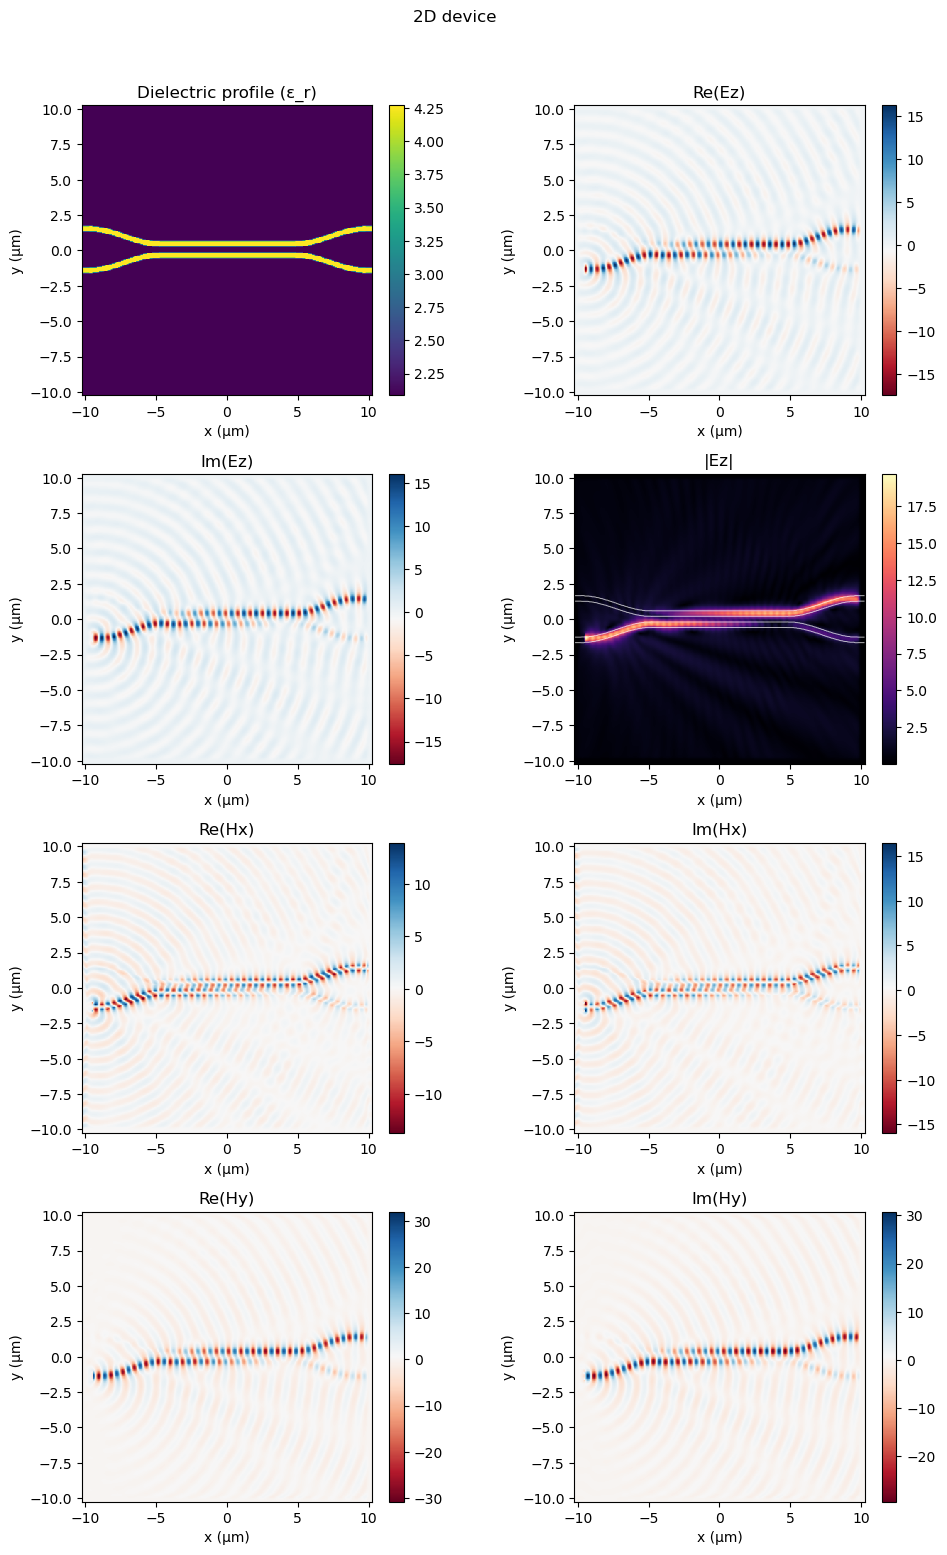

In [4]:
cell_x, cell_y = cell
plot_fields_2d(eps, Ez_full, Hx_mid=Hx_full, Hy_mid=Hy_full, cell_x_um=cell[0], cell_y_um=cell[1], abs_scale="linear")

pml_px: 13, expected non-PML crop: (H=385, W=385)
-----------
Initializing structure...
time for choose_chunkdivision = 0.00743318 s
Working in 2D dimensions.
Computational cell is 20.55 x 20.55 x 0 with resolution 20
     block, center = (0.360299,-8.94837,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.90621,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.86404,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.82187,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.7

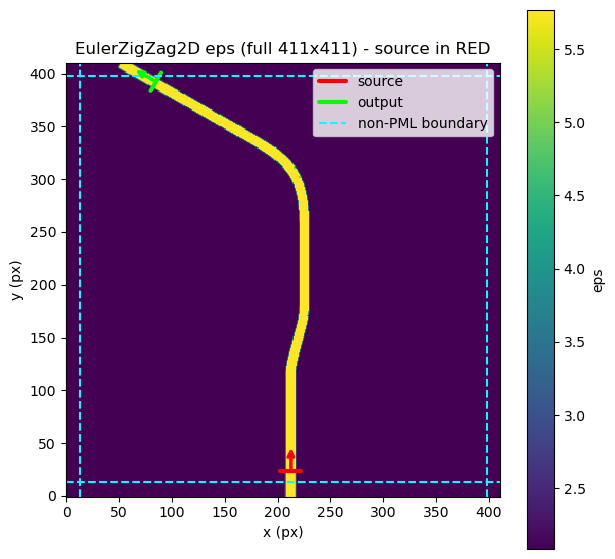

Non-PML interior: y=[13, 398], x=[13, 398]
Device should stay INSIDE the cyan dashed box
RED = source (input), GREEN = output monitor


In [10]:
# --- EulerZigZag2D example ---
# Restart kernel if you modified euler_bend_device.py
from importlib import reload
import euler_bend_device
reload(euler_bend_device)
from euler_bend_device import EulerZigZag2D

# Target: larger non-PML crop to fit more varied bends/angles
crop_px = 384  # non-PML interior pixels
resolution = 20
assert resolution >= 18

# Sample a diverse geometry (angles, turns, rotations) within the larger window
rng = np.random.default_rng(0)
eb = EulerZigZag2D(
    wg_width_um=float(rng.uniform(0.40, 0.55)),
    wavelength_um=1.55,
    resolution=resolution,
    dpml=2.0/3.0,
    crop_px=crop_px,
    n_zigs=int(rng.integers(1, 4)),
    start_up=bool(rng.integers(0, 2)),
    end_with_turn=bool(rng.random() < 0.5),
    end_turn_deg=float(rng.choice([60.0, 75.0, 90.0])),
    R_min_um=float(rng.uniform(1.2, 3.0)),
    straight_x_um=float(rng.uniform(0.5, 3.5)),
    straight_y_um=float(rng.uniform(0.2, 1.8)),
    lead_x_um=float(rng.uniform(1.0, 4.0)),
    min_straight_input_um=float(rng.uniform(2.0, 6.0)),
    bend_angle_deg=float(rng.choice([15.0, 30.0, 45.0, 60.0, 75.0, 90.0])),
    lead_extend_through_pml=True,
    y0_um=float(rng.uniform(-2.5, 2.5)),
    path_rotation_deg=float(rng.choice([0.0, 90.0, 180.0, 270.0])),
)

# compute expected crop size
p = int(round(eb.dpml * eb.resolution))
expected_H = int(round(eb.cell_y * eb.resolution)) - 2 * p
expected_W = int(round(eb.cell_x * eb.resolution)) - 2 * p
print(f"pml_px: {p}, expected non-PML crop: (H={expected_H}, W={expected_W})")

# visualize eps + source location (full grid)
eps_full, (Lx_full, Ly_full) = eb.get_eps_and_cell()
ny_full, nx_full = eps_full.shape
print(f"Full grid: ({ny_full}, {nx_full})")

plt.figure(figsize=(7, 7))
plt.title(f"EulerZigZag2D eps (full {ny_full}x{nx_full}) - source in RED")
plt.imshow(eps_full, origin="lower", aspect="equal", interpolation="nearest")
plt.gca().set_aspect("equal", adjustable="box")

# Draw source as a red line with arrow showing propagation direction
src_info = eb.get_source_region_px(crop_pml=False)
sx, sy = src_info['line_start_px']
ex, ey = src_info['line_end_px']
cx, cy = src_info['center_px']
dx, dy = src_info['direction_px']

# Draw source line
plt.plot([sx, ex], [sy, ey], color='red', linewidth=3, solid_capstyle='round', label='source')

# Draw arrow showing propagation direction (from source center, pointing into the device)
arrow_len = 25  # pixels
plt.annotate('', xy=(cx + dx * arrow_len, cy + dy * arrow_len), xytext=(cx, cy),
             arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

# Draw output monitor as a green line with arrow showing output direction
out_info = eb.get_output_region_px(crop_pml=False)
osx, osy = out_info['line_start_px']
oex, oey = out_info['line_end_px']
ocx, ocy = out_info['center_px']
odx, ody = out_info['direction_px']

# Draw output monitor line
plt.plot([osx, oex], [osy, oey], color='lime', linewidth=3, solid_capstyle='round', label='output')

# Draw arrow showing output direction (light exiting the device)
plt.annotate('', xy=(ocx + odx * arrow_len, ocy + ody * arrow_len), xytext=(ocx, ocy),
             arrowprops=dict(arrowstyle='->', color='lime', lw=2.5))

# Draw non-PML boundary (cyan dashed rectangle)
# Device should fit INSIDE this box
plt.axhline(y=p, color='cyan', linestyle='--', linewidth=1.5, label='non-PML boundary')
plt.axhline(y=ny_full - p, color='cyan', linestyle='--', linewidth=1.5)
plt.axvline(x=p, color='cyan', linestyle='--', linewidth=1.5)
plt.axvline(x=nx_full - p, color='cyan', linestyle='--', linewidth=1.5)

plt.colorbar(label="eps")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.legend(loc='upper right')
plt.show()

print(f"Non-PML interior: y=[{p}, {ny_full-p}], x=[{p}, {nx_full-p}]")
print("Device should stay INSIDE the cyan dashed box")
print("RED = source (input), GREEN = output monitor")



-----------
Initializing structure...
time for choose_chunkdivision = 0.00643992 s
Working in 2D dimensions.
Computational cell is 22.6667 x 22.6667 x 0 with resolution 18
     block, center = (0.360299,-8.94837,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.90621,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.86404,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.360299,-8.82187,0)
          size (0.044275,0.495544,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.76673,5.76673,5.76673)
     block, center = (0.

MPB solved for frequency_1(0,1,0) = 0.474916 after 14 iters
MPB solved for frequency_1(0,1.39462,0) = 0.64112 after 7 iters
MPB solved for frequency_1(0,1.40439,0) = 0.64516 after 5 iters
MPB solved for frequency_1(0,1.40439,0) = 0.645161 after 1 iters
on time step 714 (time=19.8333), 0.00560477 s/step
on time step 1449 (time=40.25), 0.0054438 s/step
on time step 2199 (time=61.0833), 0.00533415 s/step
on time step 2874 (time=79.8333), 0.00593385 s/step
on time step 3493 (time=97.0278), 0.00646875 s/step
on time step 4201 (time=116.694), 0.00565822 s/step
on time step 4931 (time=136.972), 0.00548675 s/step
on time step 5658 (time=157.167), 0.0055066 s/step
on time step 6417 (time=178.25), 0.00527416 s/step
on time step 7154 (time=198.722), 0.00542962 s/step
on time step 7767 (time=215.75), 0.00652975 s/step
on time step 8406 (time=233.5), 0.00626021 s/step


run 0 finished at t = 247.3611111111111 (8905 timesteps)
MPB solved for frequency_1(0,1.54929,0) = 0.704862 after 17 iters
MPB solved for frequency_1(0,1.40393,0) = 0.64497 after 6 iters
MPB solved for frequency_1(0,1.40439,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.40439,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.404390,0.000000)


MPB solved for frequency_1(1.54929,0,0) = 0.693691 after 18 iters
MPB solved for frequency_1(1.43122,0,0) = 0.645054 after 7 iters
MPB solved for frequency_1(1.43148,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.43148,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.431480,-0.000000,0.000000)
=== EulerZigZag2D S-parameters ===
S11 = -0.01712+0.02452j, |S11|² = 0.0008947
S21 = -0.2108-0.6538j, |S21|² = 0.4718
Σ|S·1|² = 0.4727 (should be ≤1)
Sim returned eps_full: (408, 408), cell: (22.666666666666664, 22.666666666666664)

S11 (reflection): -0.01712+0.02452j, |S11|² = 0.0008947
S21 (transmission): -0.2108-0.6538j, |S21|² = 0.4718
Total guided power: 0.4727

Cropped shape: (384, 384)


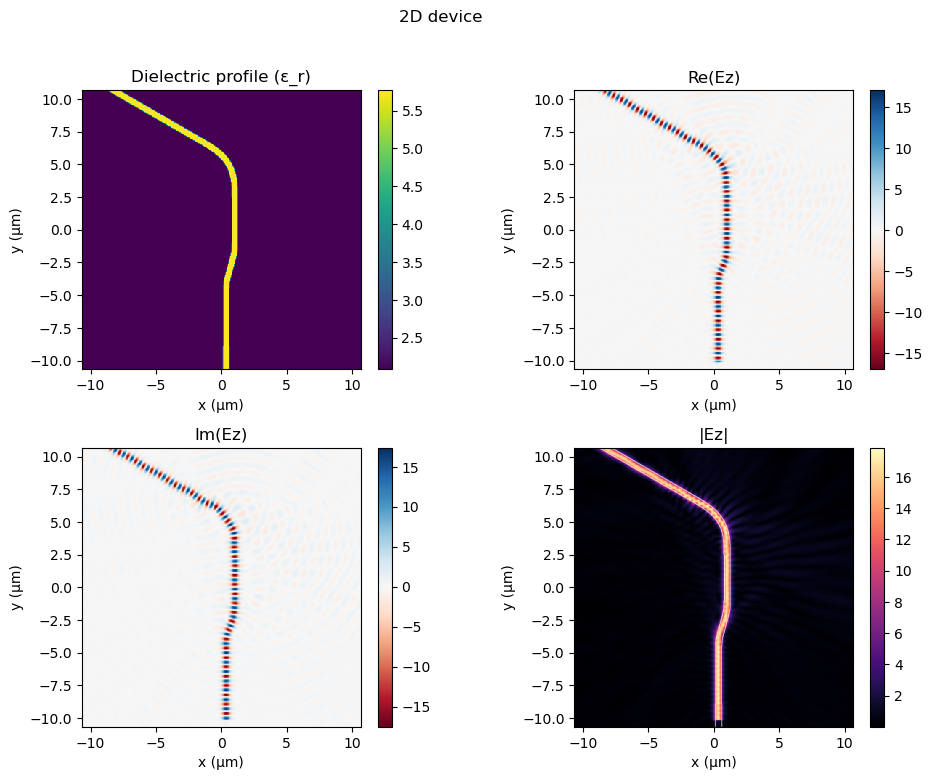

In [6]:
# Run FDTD simulation and crop to non-PML interior
# Expect eps/Ez cropped shape: (384, 384) with the current crop_px
# Now also returns S-parameters: S[(1,1)] = S11 (reflection), S[(2,1)] = S21 (transmission)
eps_full, Ez_full, S, cell = eb.run_sim(decay_tol=1e-6)
print(f"Sim returned eps_full: {eps_full.shape}, cell: {cell}")

# S-parameters summary
print(f"\nS11 (reflection): {S[(1,1)]:.4g}, |S11|² = {abs(S[(1,1)])**2:.4g}")
print(f"S21 (transmission): {S[(2,1)]:.4g}, |S21|² = {abs(S[(2,1)])**2:.4g}")
print(f"Total guided power: {abs(S[(1,1)])**2 + abs(S[(2,1)])**2:.4g}")

# Crop PML
p = int(round(eb.dpml * eb.resolution))
eps = eps_full[p:-p, p:-p]
Ez = Ez_full[p:-p, p:-p]
print(f"\nCropped shape: {eps.shape}")

# Plot cropped fields
Lx_nonpml = cell[0] - 2 * eb.dpml
Ly_nonpml = cell[1] - 2 * eb.dpml
plot_fields_2d(eps, Ez, cell_x_um=Lx_nonpml, cell_y_um=Ly_nonpml, abs_scale="linear")


Generated 16 devices
-----------
Initializing structure...
time for choose_chunkdivision = 0.00225306 s
Working in 2D dimensions.
Computational cell is 12 x 12 x 0 with resolution 24
     block, center = (2.79057,-2.39135,0)
          size (0.04516,0.486499,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.59594,5.59594,5.59594)
     block, center = (2.74756,-2.39135,0)
          size (0.04516,0.486499,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.59594,5.59594,5.59594)
     block, center = (2.70455,-2.39135,0)
          size (0.04516,0.486499,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.59594,5.59594,5.59594)
     block, center = (2.66154,-2.39135,0)
          size (0.04516,0.486499,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.59594,5.59594,5.59594)
     block, c

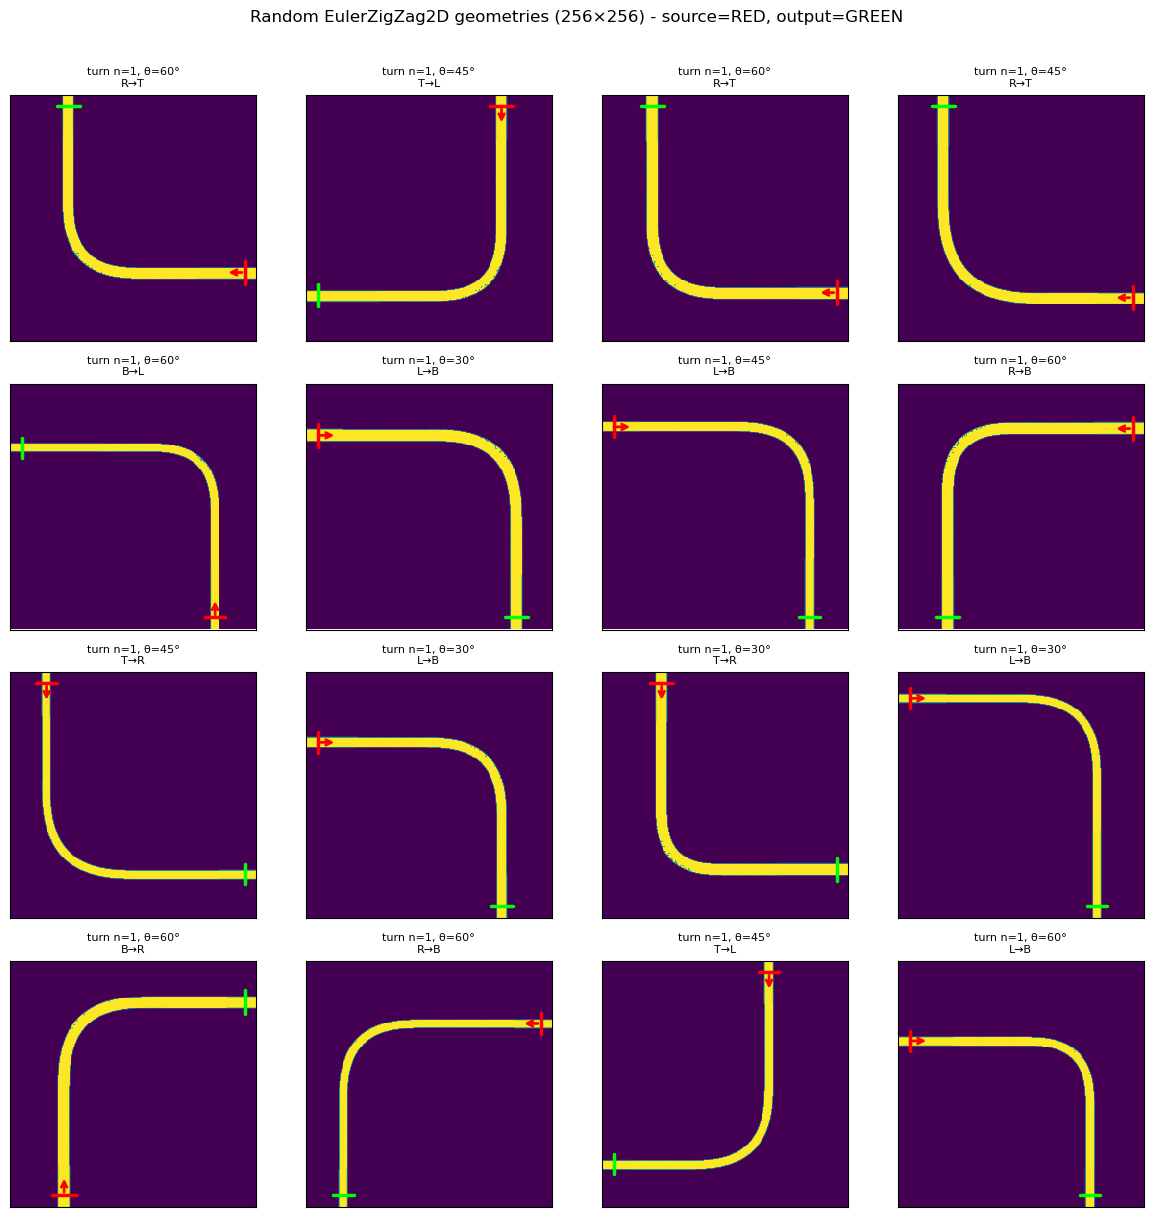

Each cropped eps shape: (256, 256)
Edge legend: L=left, R=right, T=top, B=bottom
RED = source (input), GREEN = output monitor


In [3]:
# --- Random Euler ZigZag device geometries (full eps, 256x256 crops) ---
# Shows variety in the dataset: different radii, zig counts, and (optionally) a *net* turning device.
# The net turning device enables I/O edge pairs like bottom->right, top->right, bottom->left, etc.
# Uses rejection sampling to ensure all devices fit in the 256x256 non-PML region.
# Source location is highlighted in RED on each geometry.

from importlib import reload
import euler_bend_device
reload(euler_bend_device)
from euler_bend_device import EulerZigZag2D

rng = np.random.default_rng(42)

n_devices = 16
n_cols = 4
n_rows = int(np.ceil(n_devices / n_cols))

# Fixed grid params for 256x256 crop
crop_px = 256
resolution = 24
assert resolution >= 18

dpml = 2.0 / 3.0
pml_px = int(round(dpml * resolution))
full_px = crop_px + 2 * pml_px
cell_um = full_px / resolution

EDGE_BY_ROT = {0: "L", 90: "B", 180: "R", 270: "T"}

def _rot_edge(edge: str, rot_deg: int) -> str:
    """Rotate edge label by rot_deg (CCW): L->B->R->T->L."""
    order = ["L", "B", "R", "T"]
    k = int((rot_deg // 90) % 4)
    return order[(order.index(edge) + k) % 4]


def _edge_pair_for_device(path_rotation_deg: int, end_with_turn: bool, start_up: bool) -> tuple[str, str]:
    """Return (in_edge, out_edge) in {L,R,T,B} for our construction."""
    rot = int(path_rotation_deg)

    # Base construction in local coords:
    # - straight-through: in=L, out=R
    # - net turn (end_with_turn=True): in=L, out=T if start_up else out=B
    if not end_with_turn:
        in0, out0 = "L", "R"
    else:
        in0, out0 = "L", ("T" if start_up else "B")

    return _rot_edge(in0, rot), _rot_edge(out0, rot)


devices = []
max_attempts = 100

for i in range(n_devices):
    for attempt in range(max_attempts):
        try:
            # Decide whether this sample is straight-through or a net-turn device.
            # Net-turn devices are the ones that produce adjacent-edge I/O pairs.
            end_with_turn = bool(rng.random() < 0.5)

            # Randomize geometry parameters
            if end_with_turn:
                # Net-turn framework: final turn is 90° (so I/O hits adjacent edges),
                # but we still allow multiple zigs and smaller intermediate bend angles.
                n_zigs = int(rng.choice([1, 2, 3]))
                bend_angle = float(rng.choice([30, 45, 60]))  # intermediate zigs
                end_turn_deg = 90.0                           # final terminating turn
            else:
                n_zigs = int(rng.choice([1, 2, 3]))
                bend_angle = float(rng.choice([30, 45, 60, 90]))
                end_turn_deg = None

            start_up = bool(rng.choice([True, False]))  # controls turn direction when end_with_turn=True
            R_min = float(rng.uniform(1.5, 2.5))
            straight_x = float(rng.uniform(0.5, 2.0))
            straight_y = float(rng.uniform(0.2, 1.0))
            lead_x = float(rng.uniform(1.0, 3.0))
            y0 = float(rng.uniform(-1.5, 1.5))
            wg_width = float(rng.uniform(0.35, 0.55))
            # Rotate the whole device: 0=left, 90=bottom, 180=right, 270=top
            path_rotation = int(rng.choice([0, 90, 180, 270]))
            min_straight_input = float(rng.uniform(2.0, 4.0))

            dev = EulerZigZag2D(
                wg_width_um=wg_width,
                wavelength_um=1.55,
                resolution=resolution,
                dpml=dpml,
                cell_x_um=cell_um,
                cell_y_um=cell_um,
                n_zigs=n_zigs,
                start_up=start_up,
                end_with_turn=end_with_turn,
                end_turn_deg=end_turn_deg,
                R_min_um=R_min,
                straight_x_um=straight_x,
                straight_y_um=straight_y,
                lead_x_um=lead_x,
                min_straight_input_um=min_straight_input,
                bend_angle_deg=bend_angle,
                lead_extend_through_pml=True,
                y0_um=y0,
                fit_margin_um=0.5,
                path_rotation_deg=float(path_rotation),
            )
            devices.append(dev)
            break
        except ValueError:
            # Doesn't fit - try again with different params
            continue
    else:
        print(f"Warning: couldn't generate device {i} after {max_attempts} attempts")

print(f"Generated {len(devices)} devices")

# Plot all geometries with source highlighted in red
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes = np.asarray(axes).reshape(n_rows, n_cols)

for i in range(n_rows * n_cols):
    ax = axes[i // n_cols, i % n_cols]
    if i >= len(devices):
        ax.axis("off")
        continue

    dev = devices[i]
    eps_full, _ = dev.get_eps_and_cell()
    # Crop to crop_px x crop_px non-PML
    p = int(round(dev.dpml * dev.resolution))
    eps = eps_full[p:-p, p:-p]

    ax.imshow(eps, origin="lower", aspect="equal", cmap="viridis", interpolation="nearest")

    # Draw source as a red line with arrow showing propagation direction
    src_info = dev.get_source_region_px(crop_pml=True)
    sx, sy = src_info["line_start_px"]
    ex, ey = src_info["line_end_px"]
    cx, cy = src_info["center_px"]
    dx, dy = src_info["direction_px"]

    ax.plot([sx, ex], [sy, ey], color="red", linewidth=2.5, solid_capstyle="round")

    arrow_len = 20  # pixels
    ax.annotate(
        "",
        xy=(cx + dx * arrow_len, cy + dy * arrow_len),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="->", color="red", lw=2),
    )

    # Draw output monitor as a green line with arrow
    out_info = dev.get_output_region_px(crop_pml=True)
    osx, osy = out_info["line_start_px"]
    oex, oey = out_info["line_end_px"]
    ocx, ocy = out_info["center_px"]
    odx, ody = out_info["direction_px"]

    ax.plot([osx, oex], [osy, oey], color="lime", linewidth=2.5, solid_capstyle="round")
    ax.annotate(
        "",
        xy=(ocx + odx * arrow_len, ocy + ody * arrow_len),
        xytext=(ocx, ocy),
        arrowprops=dict(arrowstyle="->", color="lime", lw=2),
    )

    ax.set_xticks([])
    ax.set_yticks([])

    rot = int(dev.path_rotation_deg)
    in_edge, out_edge = _edge_pair_for_device(rot, bool(getattr(dev, "end_with_turn", False)), bool(dev.start_up))
    turn_tag = "turn" if bool(getattr(dev, "end_with_turn", False)) else "thru"
    ax.set_title(
        f"{turn_tag} n={dev.n_zigs}, θ={int(dev.bend_angle_deg)}°\n{in_edge}→{out_edge}",
        fontsize=8,
    )

fig.suptitle(
    f"Random EulerZigZag2D geometries ({eps.shape[0]}×{eps.shape[1]}) - source=RED, output=GREEN",
    y=1.01,
)
fig.tight_layout()
plt.show()

print(f"Each cropped eps shape: {eps.shape}")
print("Edge legend: L=left, R=right, T=top, B=bottom")
print("RED = source (input), GREEN = output monitor")



Generated 16 devices
-----------
Initializing structure...
time for choose_chunkdivision = 0.00215316 s
Working in 2D dimensions.
Computational cell is 22.6667 x 22.6667 x 0 with resolution 18
     block, center = (-4.59038,-4.29805,0)
          size (0.0590905,0.53372,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (-4.59038,-4.24178,0)
          size (0.0590905,0.53372,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (-4.59038,-4.1855,0)
          size (0.0590905,0.53372,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (-4.59038,-4.12922,0)
          size (0.0590905,0.53372,1e+20)
          axes (0,1,0), (-1,0,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
    

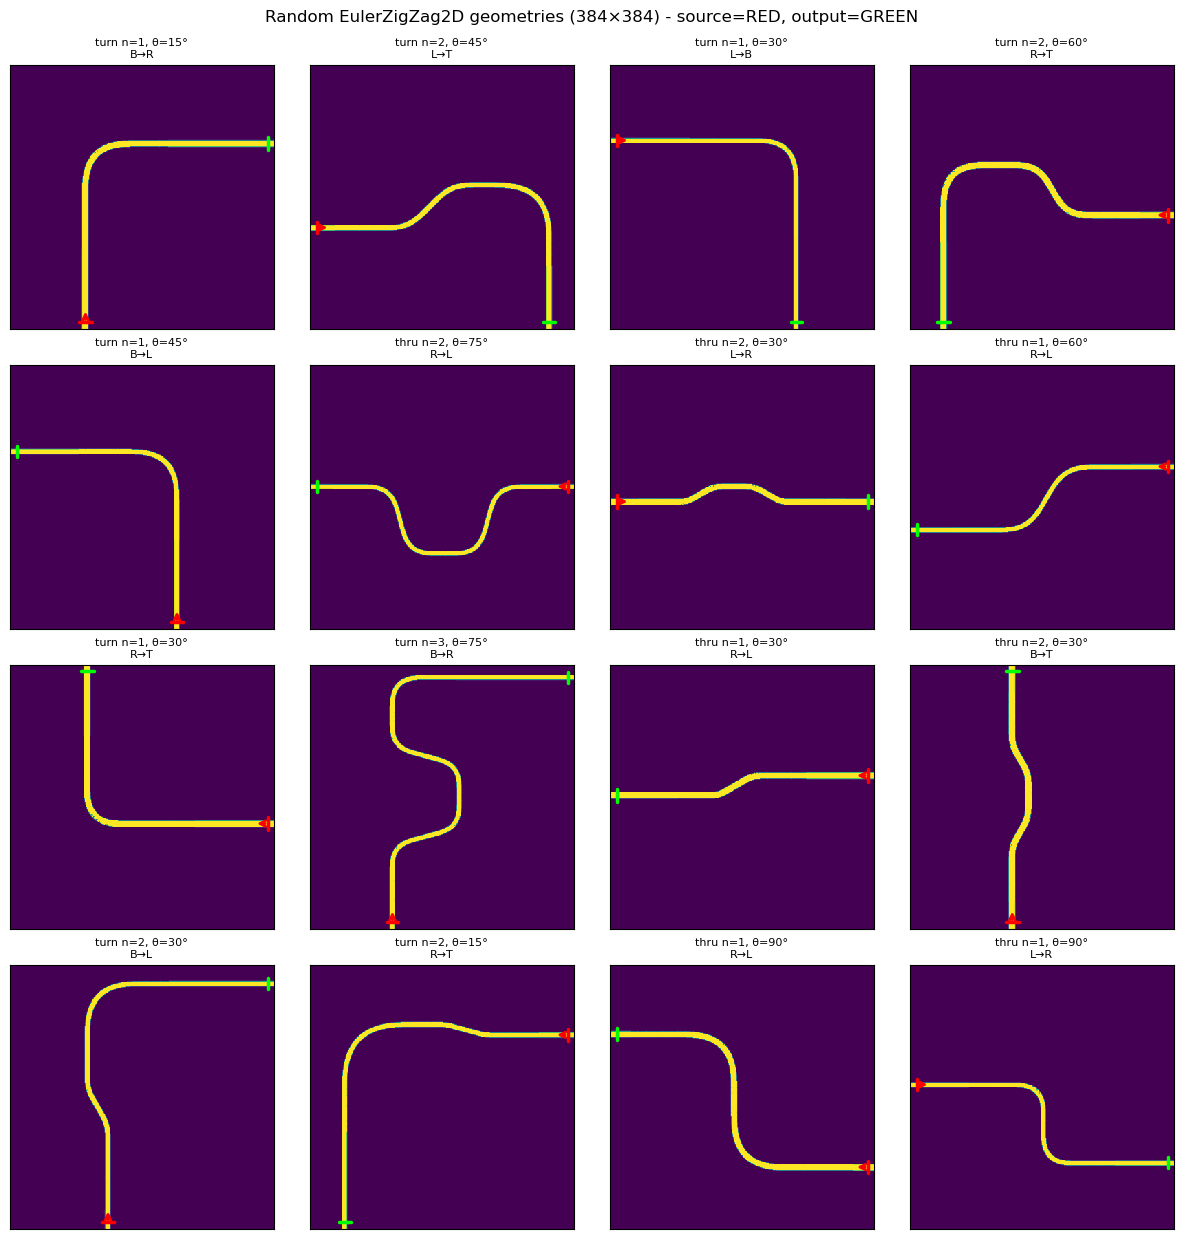

Each cropped eps shape: (384, 384)
Edge legend: L=left, R=right, T=top, B=bottom
RED = source (input), GREEN = output monitor


In [ ]:
# Full notebook snippet: generate EulerZigZag2D devices + plot eps with input/output overlays

from importlib import reload
import numpy as np
import matplotlib.pyplot as plt

import euler_bend_device
reload(euler_bend_device)
from euler_bend_device import EulerZigZag2D


# ----------------------------
# Helpers: edge labels for titles
# ----------------------------
def _rot_edge(edge: str, rot_deg: int) -> str:
    order = ["L", "B", "R", "T"]
    k = int((rot_deg // 90) % 4)
    return order[(order.index(edge) + k) % 4]

def _edge_pair_for_device(path_rotation_deg: int, end_with_turn: bool, start_up: bool) -> tuple[str, str]:
    rot = int(path_rotation_deg)
    if not end_with_turn:
        in0, out0 = "L", "R"
    else:
        in0, out0 = "L", ("T" if start_up else "B")
    return _rot_edge(in0, rot), _rot_edge(out0, rot)


# ----------------------------
# Config
# ----------------------------
rng = np.random.default_rng(123)

n_devices = 16
n_cols = 4
n_rows = int(np.ceil(n_devices / n_cols))

crop_px = 384
resolution = 20
dpml = 2.0 / 3.0
wavelength_um = 1.55

max_attempts = 250


# ----------------------------
# Generate devices
# ----------------------------
devices = []
for i in range(n_devices):
    for attempt in range(max_attempts):
        try:
            end_with_turn = bool(rng.random() < 0.5)

            # Keep turn devices axis-aligned at the edges by letting the device snap/force it.
            # (If your class doesn't have these flags, remove them.)
            force_turn_ports_axis_aligned = True
            quantize_grid = True

            if end_with_turn:
                n_zigs = int(rng.choice([1, 2, 3]))
                bend_angle = float(rng.choice([15, 30, 45, 60, 75]))
                end_turn_deg = None  # let device enforce axis-aligned edge ports
            else:
                n_zigs = int(rng.choice([1, 2, 3, 4]))
                bend_angle = float(rng.choice([15, 30, 45, 60, 75, 90]))
                end_turn_deg = None

            start_up = bool(rng.integers(0, 2))
            R_min = float(rng.uniform(1.2, 3.0))
            straight_x = float(rng.uniform(0.5, 3.5))
            straight_y = float(rng.uniform(0.2, 1.8))
            lead_x = float(rng.uniform(1.0, 4.0))
            y0 = float(rng.uniform(-2.5, 2.5))
            wg_width = float(rng.uniform(0.35, 0.55))
            path_rotation = float(rng.choice([0.0, 90.0, 180.0, 270.0]))
            min_straight_input = float(rng.uniform(2.0, 6.0))

            dev = EulerZigZag2D(
                wg_width_um=wg_width,
                wavelength_um=wavelength_um,
                resolution=resolution,
                dpml=dpml,
                crop_px=crop_px,

                n_zigs=n_zigs,
                start_up=start_up,
                end_with_turn=end_with_turn,
                end_turn_deg=end_turn_deg,

                R_min_um=R_min,
                straight_x_um=straight_x,
                straight_y_um=straight_y,
                lead_x_um=lead_x,
                min_straight_input_um=min_straight_input,
                bend_angle_deg=bend_angle,
                lead_extend_through_pml=True,
                y0_um=y0,
                fit_margin_um=0.5,
                path_rotation_deg=path_rotation,

                # require your updated class; remove if not present
                quantize_grid=quantize_grid,
                force_turn_ports_axis_aligned=force_turn_ports_axis_aligned,
            )

            devices.append(dev)
            break

        except ValueError:
            continue

    else:
        print(f"Warning: couldn't generate device {i} after {max_attempts} attempts")

print(f"Generated {len(devices)} devices")


# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12), constrained_layout=True)
axes = np.asarray(axes).reshape(n_rows, n_cols)

for i in range(n_rows * n_cols):
    ax = axes[i // n_cols, i % n_cols]
    if i >= len(devices):
        ax.axis("off")
        continue

    dev = devices[i]
    eps_full, _ = dev.get_eps_and_cell()
    p = int(round(dev.dpml * dev.resolution))
    eps = eps_full[p:-p, p:-p]

    H, W = eps.shape
    extent = (-0.5, W - 0.5, -0.5, H - 0.5)

    ax.imshow(
        eps,
        origin="lower",
        aspect="equal",
        cmap="viridis",
        interpolation="nearest",
        extent=extent,
    )

    # lock axes to prevent any autoscale weirdness from later artists
    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(-0.5, H - 0.5)
    ax.set_autoscale_on(False)

    arrow_len = 20

    src_info = dev.get_source_region_px(crop_pml=True)
    sx, sy = src_info["line_start_px"]
    ex, ey = src_info["line_end_px"]
    cx, cy = src_info["center_px"]
    dx, dy = src_info["direction_px"]

    ax.plot([sx, ex], [sy, ey], color="red", linewidth=2.5,
            solid_capstyle="round", clip_on=True)
    ax.annotate(
        "",
        xy=(cx + dx * arrow_len, cy + dy * arrow_len),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="->", color="red", lw=2),
        annotation_clip=True,
    )

    out_info = dev.get_output_region_px(crop_pml=True)
    osx, osy = out_info["line_start_px"]
    oex, oey = out_info["line_end_px"]
    ocx, ocy = out_info["center_px"]
    odx, ody = out_info["direction_px"]

    ax.plot([osx, oex], [osy, oey], color="lime", linewidth=2.5,
            solid_capstyle="round", clip_on=True)
    ax.annotate(
        "",
        xy=(ocx + odx * arrow_len, ocy + ody * arrow_len),
        xytext=(ocx, ocy),
        arrowprops=dict(arrowstyle="->", color="lime", lw=2),
        annotation_clip=True,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    rot = int(dev.path_rotation_deg)
    in_edge, out_edge = _edge_pair_for_device(
        rot, bool(getattr(dev, "end_with_turn", False)), bool(dev.start_up)
    )
    turn_tag = "turn" if bool(getattr(dev, "end_with_turn", False)) else "thru"
    ax.set_title(f"{turn_tag} n={dev.n_zigs}, θ={int(dev.bend_angle_deg)}°\n{in_edge}→{out_edge}", fontsize=8)

fig.suptitle(
    f"Random EulerZigZag2D geometries ({eps.shape[0]}×{eps.shape[1]}) - source=RED, output=GREEN",
    y=1.02,
)
plt.show()

print(f"Each cropped eps shape: {eps.shape}")
print("Edge legend: L=left, R=right, T=top, B=bottom")
print("RED = source (input), GREEN = output monitor")


Running FDTD on devices: [np.int64(8), np.int64(15)]

Device 8: mode=turn, edges=R->T, n_zigs=1, bend_angle=30.0°, R_min=1.68µm, rotation=180.0°
-----------
Initializing structure...
time for choose_chunkdivision = 0.00204992 s
Working in 2D dimensions.
Computational cell is 22.6667 x 22.6667 x 0 with resolution 18
     block, center = (4.41141,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.35526,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.29911,-2.16585,0)
          size (0.0589573,0.534543,1e+20)


          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.24296,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.18681,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.13066,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.07451,-2.16585,0)
          size (0.0589573,0.534543,1e+20)
          axes (-1,0,0), (-0,-1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.93757,5.93757,5.93757)
     block, center = (4.01836,-2.16585,0)
          size (0.0589573,0

MPB solved for frequency_1(-1,0,0) = 0.464724 after 14 iters
MPB solved for frequency_1(-1.42801,0,0) = 0.641037 after 8 iters
MPB solved for frequency_1(-1.43818,0,0) = 0.64516 after 5 iters
MPB solved for frequency_1(-1.43818,0,0) = 0.645161 after 1 iters
on time step 659 (time=18.3056), 0.00607122 s/step
on time step 1343 (time=37.3056), 0.00584993 s/step
on time step 2032 (time=56.4444), 0.00581056 s/step
on time step 2713 (time=75.3611), 0.00587548 s/step
on time step 3398 (time=94.3889), 0.00583994 s/step
on time step 4121 (time=114.472), 0.00553622 s/step
on time step 4767 (time=132.417), 0.0061984 s/step
on time step 5435 (time=150.972), 0.00599505 s/step
on time step 6107 (time=169.639), 0.0059574 s/step
on time step 6793 (time=188.694), 0.00583564 s/step
on time step 7505 (time=208.472), 0.00562077 s/step
on time step 8219 (time=228.306), 0.00560638 s/step


run 0 finished at t = 247.3611111111111 (8905 timesteps)
MPB solved for frequency_1(1.57207,0,0) = 0.699286 after 18 iters
MPB solved for frequency_1(1.43789,0,0) = 0.645044 after 7 iters
MPB solved for frequency_1(1.43818,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.43818,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.438183,-0.000000,0.000000)


MPB solved for frequency_1(0,1.57207,0) = 0.699168 after 18 iters
MPB solved for frequency_1(0,1.43817,0) = 0.645045 after 7 iters
MPB solved for frequency_1(0,1.43845,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.43845,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.438453,0.000000)


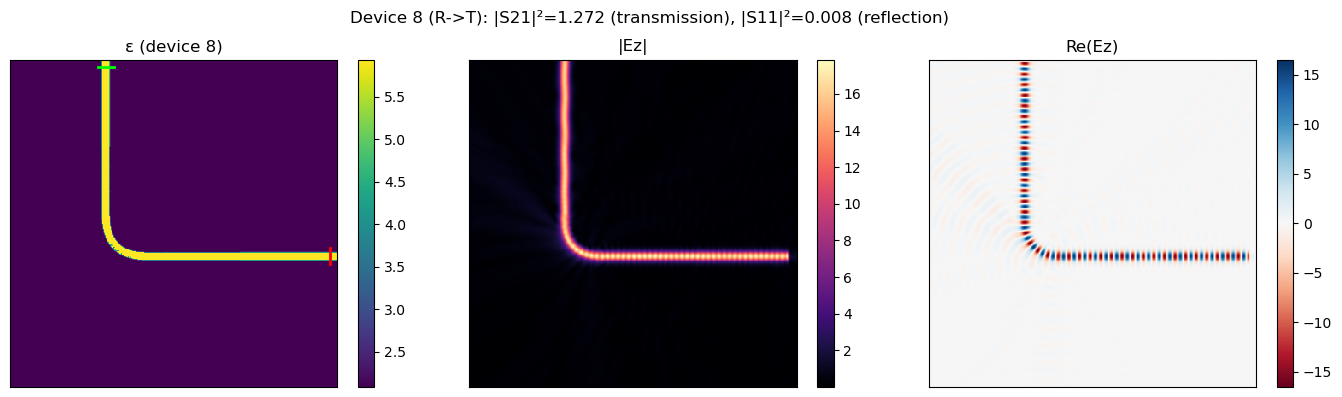


Device 15: mode=thru, edges=L->R, n_zigs=1, bend_angle=90.0°, R_min=1.39µm, rotation=0.0°
-----------
Initializing structure...
time for choose_chunkdivision = 0.00271606 s
Working in 2D dimensions.
Computational cell is 22.6667 x 22.6667 x 0 with resolution 18
     block, center = (-5.98075,0.986612,0)
          size (0.059384,0.405837,1e+20)
          axes (1,0,0), (-0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.61906,4.61906,4.61906)
     block, center = (-5.9242,0.986612,0)
          size (0.059384,0.405837,1e+20)
          axes (1,0,0), (-0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.61906,4.61906,4.61906)
     block, center = (-5.86764,0.986612,0)
          size (0.059384,0.405837,1e+20)
          axes (1,0,0), (-0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.61906,4.61906,4.61906)
     block, center = (-5.81108,0.986612,0)
          size (0.059384,0.405837,1e+20)
          axes (1,0,0), (-0,1,0), (0,0,1)
         

MPB solved for frequency_1(1,0,0) = 0.536463 after 15 iters
MPB solved for frequency_1(1.21806,0,0) = 0.643402 after 7 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 1 iters
on time step 749 (time=20.8056), 0.00534581 s/step
on time step 1484 (time=41.2222), 0.00544769 s/step
on time step 2149 (time=59.6944), 0.00602246 s/step
on time step 2851 (time=79.1944), 0.00570505 s/step
on time step 3534 (time=98.1667), 0.00586141 s/step
on time step 4220 (time=117.222), 0.00583191 s/step
on time step 4921 (time=136.694), 0.00571262 s/step
on time step 5615 (time=155.972), 0.00576974 s/step
on time step 6293 (time=174.806), 0.00589975 s/step
on time step 6999 (time=194.417), 0.00566956 s/step
on time step 7705 (time=214.028), 0.00566709 s/step


run 0 finished at t = 224.02777777777777 (8065 timesteps)
MPB solved for frequency_1(1.38658,0,0) = 0.724011 after 17 iters
MPB solved for frequency_1(1.22025,0,0) = 0.644463 after 7 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.221700,-0.000000,0.000000)


MPB solved for frequency_1(1.38658,0,0) = 0.723997 after 17 iters
MPB solved for frequency_1(1.22025,0,0) = 0.644462 after 7 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.2217,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.221698,-0.000000,0.000000)


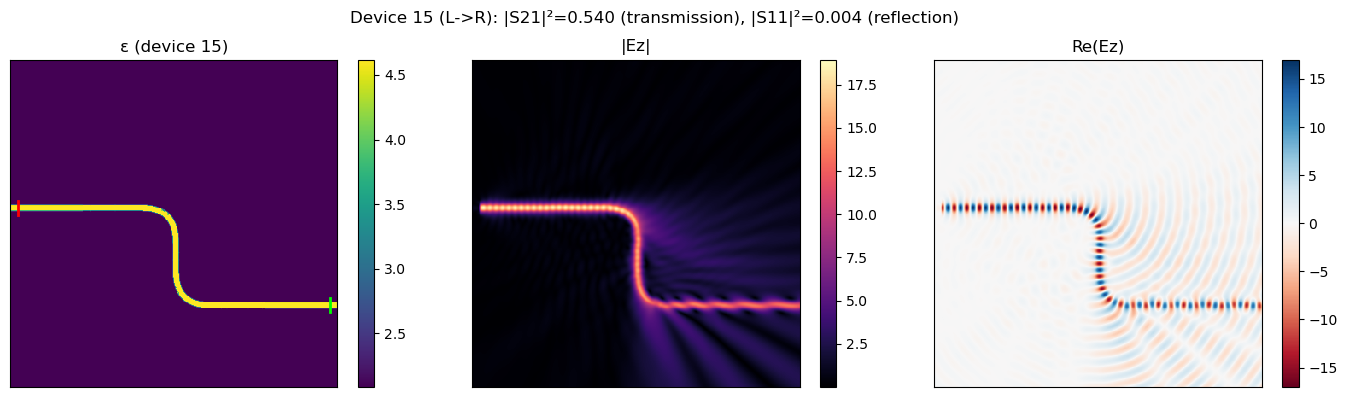

In [3]:
# --- Run FDTD on 2 random samples from the 16 devices ---
# Pick 2 random devices and run full simulation with S-parameter extraction

sample_indices = rng.choice(len(devices), size=2, replace=False)
print(f"Running FDTD on devices: {list(sample_indices)}")

for idx in sample_indices:
    dev = devices[idx]
    end_with_turn = bool(getattr(dev, "end_with_turn", False))
    rot = int(dev.path_rotation_deg)
    in_edge, out_edge = _edge_pair_for_device(rot, end_with_turn, bool(dev.start_up))

    print(f"\n{'='*60}")
    print(
        f"Device {idx}: mode={'turn' if end_with_turn else 'thru'}, "
        f"edges={in_edge}->{out_edge}, "
        f"n_zigs={dev.n_zigs}, bend_angle={dev.bend_angle_deg}°, "
        f"R_min={dev.R_min_um:.2f}µm, rotation={dev.path_rotation_deg}°"
    )
    print("=" * 60)

    # Run FDTD simulation
    eps_full, Ez_full, S, cell = dev.run_sim(decay_tol=1e-6)

    # Crop to non-PML
    p = int(round(dev.dpml * dev.resolution))
    eps = eps_full[p:-p, p:-p]
    Ez = Ez_full[p:-p, p:-p]

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Epsilon
    ax = axes[0]
    im = ax.imshow(eps, origin="lower", aspect="equal", cmap="viridis", interpolation="nearest")
    # Draw source (red) and output (green)
    src_info = dev.get_source_region_px(crop_pml=True)
    out_info = dev.get_output_region_px(crop_pml=True)
    ax.plot(
        [src_info["line_start_px"][0], src_info["line_end_px"][0]],
        [src_info["line_start_px"][1], src_info["line_end_px"][1]],
        color="red",
        linewidth=2,
    )
    ax.plot(
        [out_info["line_start_px"][0], out_info["line_end_px"][0]],
        [out_info["line_start_px"][1], out_info["line_end_px"][1]],
        color="lime",
        linewidth=2,
    )
    ax.set_title(f"ε (device {idx})")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    # |Ez|
    ax = axes[1]
    Ez_abs = np.abs(Ez)
    im = ax.imshow(Ez_abs, origin="lower", aspect="equal", cmap="magma")
    ax.set_title("|Ez|")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Re(Ez)
    ax = axes[2]
    vmax = np.abs(Ez.real).max()
    im = ax.imshow(Ez.real, origin="lower", aspect="equal", cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_title("Re(Ez)")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(
        f"Device {idx} ({in_edge}->{out_edge}): "
        f"|S21|²={abs(S[(2,1)])**2:.3f} (transmission), "
        f"|S11|²={abs(S[(1,1)])**2:.3f} (reflection)"
    )
    fig.tight_layout()
    plt.show()

